In [6]:
#1. Install libraries. Why: We install the required libraries for data analysis, visualization, machine learning, saving the model, and deployment.
!pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

In [8]:
#2. Import libraries. Why: These libraries are used for loading the data, preprocessing, training six machine learning models, evaluating performance, and saving the final model.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [10]:
#3. Load the dataset. Why: We load the dataset and view the first rows to understand the structure of the data.
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [12]:
#4. Data understanding. Why: This step helps us check data types, missing values, duplicated rows, and whether the target column is balanced or imbalanced.
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["diabetes"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0


In [14]:
#5. Data cleaning. Why: We clean the dataset by removing duplicates, handling missing values, and standardizing unclear categorical values. This makes the data suitable for machine learning.
df_clean = df.copy()

# Remove duplicated rows
df_clean.drop_duplicates(inplace=True)

# Standardize column names
df_clean.columns = df_clean.columns.str.strip()

# Replace unclear smoking history values if found
if "smoking_history" in df_clean.columns:
    df_clean["smoking_history"] = df_clean["smoking_history"].replace("No Info", "unknown")

# Remove rows with missing target
df_clean = df_clean.dropna(subset=["diabetes"])

# Fill missing numerical values using median
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values using mode
categorical_cols = df_clean.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (96146, 9)

Missing values after cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [16]:
#6. Feature engineering. Why: Feature engineering creates new meaningful health categories from numerical values. These features help make the model and interpretation more medically understandable.
# Age category
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["Child", "Young Adult", "Adult", "Senior", "Elderly"]
)

# BMI category
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# HbA1c risk category
df_clean["hba1c_category"] = pd.cut(
    df_clean["HbA1c_level"],
    bins=[0, 5.7, 6.4, 20],
    labels=["Normal", "Prediabetes", "Diabetes Range"]
)

# Blood glucose risk category
df_clean["glucose_category"] = pd.cut(
    df_clean["blood_glucose_level"],
    bins=[0, 140, 199, 500],
    labels=["Normal", "Prediabetes", "Diabetes Range"]
)

df_clean.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group,bmi_category,hba1c_category,glucose_category
0,Female,80.0,0,1,never,25.19,6.6,140,0,Elderly,Overweight,Diabetes Range,Normal
1,Female,54.0,0,0,unknown,27.32,6.6,80,0,Senior,Overweight,Diabetes Range,Normal
2,Male,28.0,0,0,never,27.32,5.7,158,0,Young Adult,Overweight,Normal,Prediabetes
3,Female,36.0,0,0,current,23.45,5.0,155,0,Adult,Normal,Normal,Prediabetes
4,Male,76.0,1,1,current,20.14,4.8,155,0,Elderly,Normal,Normal,Prediabetes


In [18]:
#7. Save the cleaned dataset. Why: Saving the cleaned dataset makes the project reproducible and gives a file ready for submission.
df_clean.to_csv("Cleaned_Diabetes_Data.csv", index=False)

print("Cleaned_Diabetes_Data.csv saved successfully.")

Cleaned_Diabetes_Data.csv saved successfully.


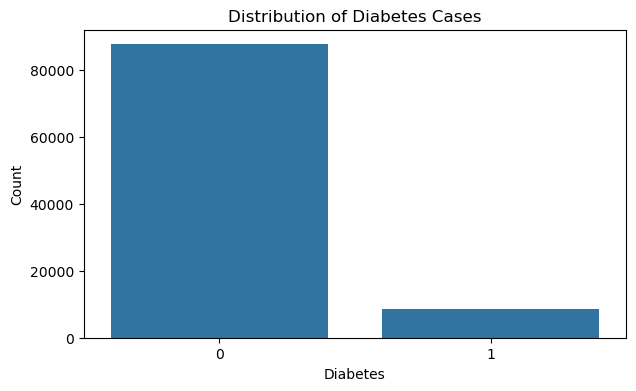

In [20]:
# Exploratory Data Analysis.
# 8. Target distribution
#Why: This plot shows the number of diabetic and non-diabetic patients. It helps identify whether the target variable is balanced or imbalanced. If one class is much larger than the other, accuracy alone may be misleading.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="diabetes")
plt.title("Distribution of Diabetes Cases")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

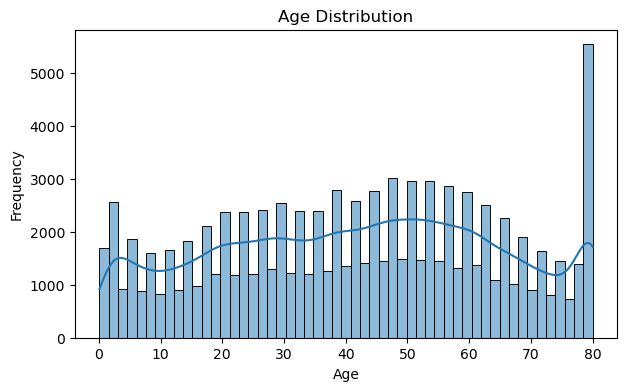

In [22]:
# 9. Age distribution. Why: This plot shows the age range of patients in the dataset. Age is important because diabetes risk often increases with age.
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

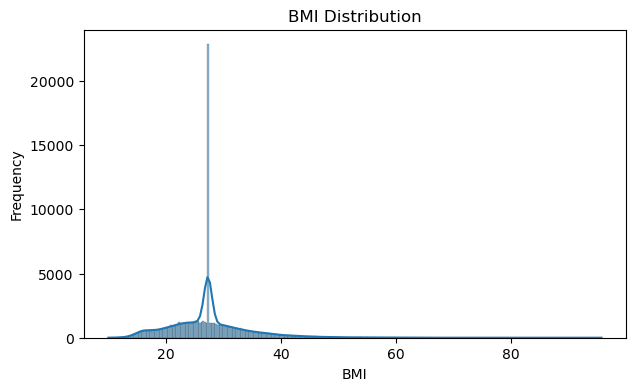

In [24]:
#10. BMI distribution. Why: This plot shows how BMI values are distributed. Higher BMI values may be associated with increased diabetes risk.
plt.figure(figsize=(7, 4))
sns.histplot(df_clean["bmi"], kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

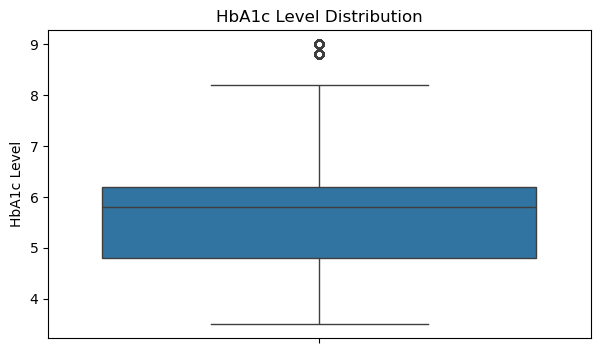

In [26]:
# 11. HbA1c distribution. Why: HbA1c is one of the most important indicators of diabetes. This plot helps detect the range of HbA1c values and possible outliers.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="HbA1c_level")
plt.title("HbA1c Level Distribution")
plt.ylabel("HbA1c Level")
plt.show()

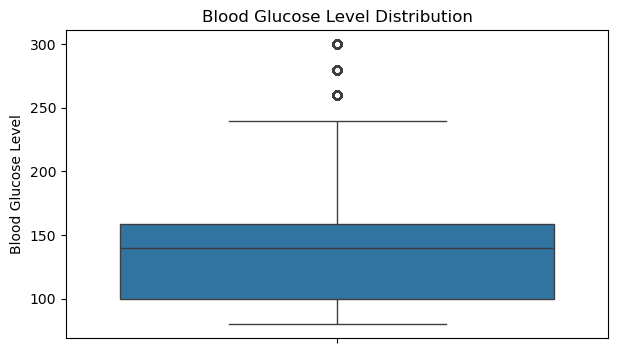

In [28]:
# 12. Blood glucose distribution. Why: This plot shows the distribution of blood glucose levels. High glucose values may indicate higher diabetes risk.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, y="blood_glucose_level")
plt.title("Blood Glucose Level Distribution")
plt.ylabel("Blood Glucose Level")
plt.show()

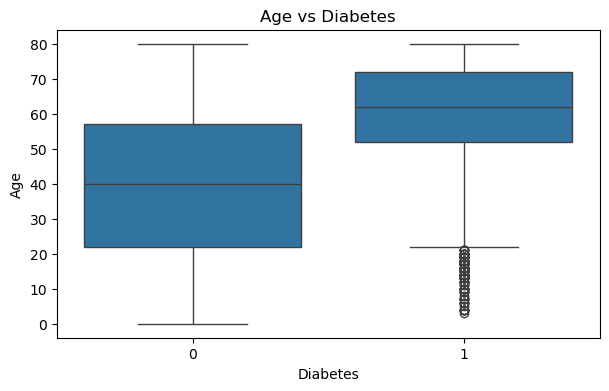

In [30]:
#13. Age vs Diabetes. Why: This plot compares age between diabetic and non-diabetic patients. If diabetic patients are generally older, age may be an important predictor.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="diabetes", y="age")
plt.title("Age vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Age")
plt.show()

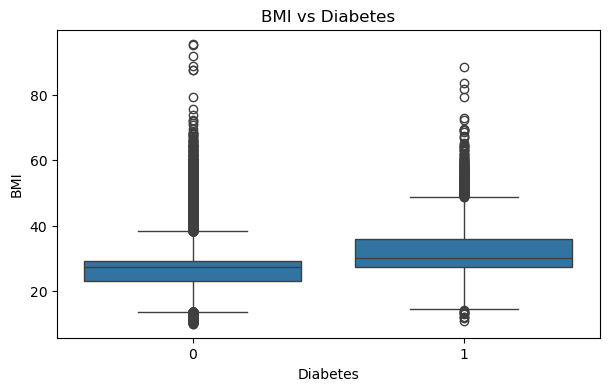

In [32]:
#14. BMI vs Diabetes. WhThis plot compares BMI values between diabetic and non-diabetic patients. Higher BMI among diabetic patients suggests BMI contributes to diabetes risk.y:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="diabetes", y="bmi")
plt.title("BMI vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("BMI")
plt.show()

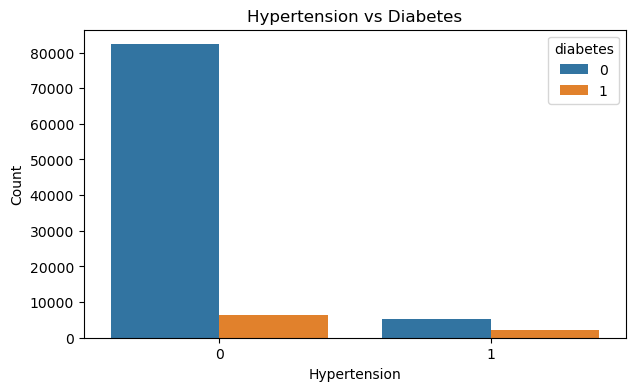

In [34]:
#15. Hypertension vs Diabetes. Why: This plot shows whether diabetes is more common among patients with hypertension. Hypertension may be associated with metabolic disease and diabetes risk.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="hypertension", hue="diabetes")
plt.title("Hypertension vs Diabetes")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.show()

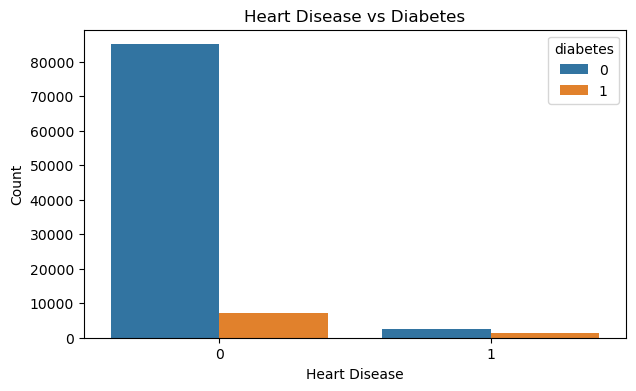

In [36]:
# 16. Heart disease vs Diabetes. Why: This plot checks the relationship between heart disease and diabetes. Diabetes and heart disease can be clinically related, so this variable may help prediction.
plt.figure(figsize=(7, 4))
sns.countplot(data=df_clean, x="heart_disease", hue="diabetes")
plt.title("Heart Disease vs Diabetes")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

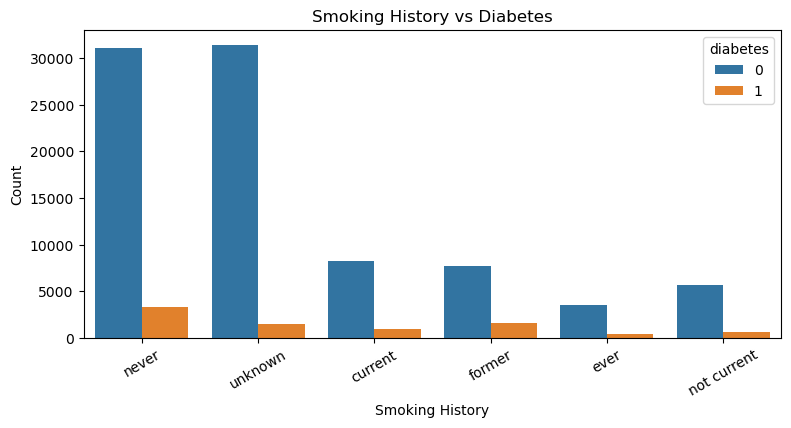

In [38]:
# 17. Smoking history vs Diabetes. Why: This plot compares diabetes cases across smoking history categories. Smoking history may not be the strongest predictor alone, but it can still contribute when combined with other features.
plt.figure(figsize=(9, 4))
sns.countplot(data=df_clean, x="smoking_history", hue="diabetes")
plt.title("Smoking History vs Diabetes")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [40]:
# 18. Correlation heatmap. Why: We separate the input features from the target variable so the model can learn patterns from X and predict y.
X = df_clean.drop(columns=["diabetes"])
y = df_clean["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (96146, 12)
Target shape: (96146,)


In [42]:
#20. Train-test split. Why: The data is split into training and testing sets. Stratification keeps the diabetes and non-diabetes ratio similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (76916, 12)
Testing set: (19230, 12)


In [44]:
# 21. Preprocessing pipeline. Why: Numerical features are scaled and categorical features are encoded. A pipeline ensures the same preprocessing is applied during training and prediction.
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical features: ['gender', 'smoking_history', 'age_group', 'bmi_category', 'hba1c_category', 'glucose_category']


In [46]:
# 22. Train six algorithms. Why: We train and compare six algorithms. The best model should be selected based on recall, F1-score, and ROC AUC, not accuracy only.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_classif, k=10)),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.878783,0.413322,0.892689,0.565031,0.963203
1,Decision Tree,0.947582,0.688804,0.739976,0.713474,0.856224
2,Random Forest,0.964535,0.863702,0.709906,0.779288,0.952951
3,SVM,0.890016,0.440330,0.911557,0.593816,0.964879
4,KNN,0.963755,0.894862,0.667453,0.764607,0.907917
5,Gradient Boosting,0.972075,0.994876,0.686910,0.812696,0.976450


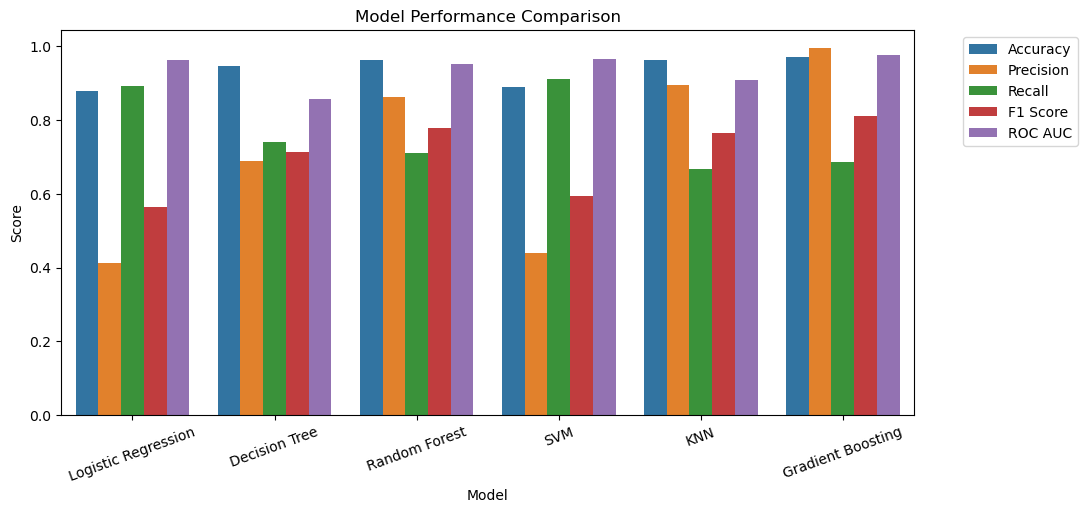

In [48]:
# 23. Model performance comparison plot. Why: This plot compares all six models across multiple metrics. It helps justify which model is best overall.
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [50]:
# 24. Hyperparameter tuning. Why: GridSearchCV tests different model settings and chooses the best combination using cross-validation.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "feature_selection__k": [8, 10, 12, "all"],
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'feature_selection__k': 'all'}
Best cross-validation F1 score:
0.7899912250244269


In [52]:
# 25. Evaluate final model. Why: This evaluates the final model using several metrics. In diabetes prediction, recall is important because missing diabetic patients can be serious.
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9692147685907436
Precision: 0.9458804523424879
Recall: 0.6904481132075472
F1 Score: 0.798227675528289
ROC AUC: 0.9611324884160369

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



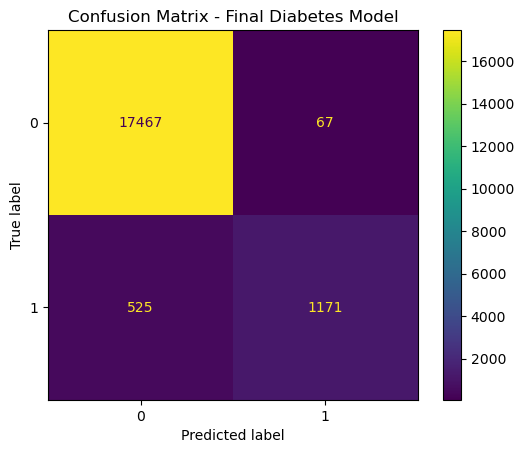

In [54]:
# 26. Confusion matrix. Why: The confusion matrix shows correct and incorrect predictions for diabetic and non-diabetic patients.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Final Diabetes Model")
plt.show()

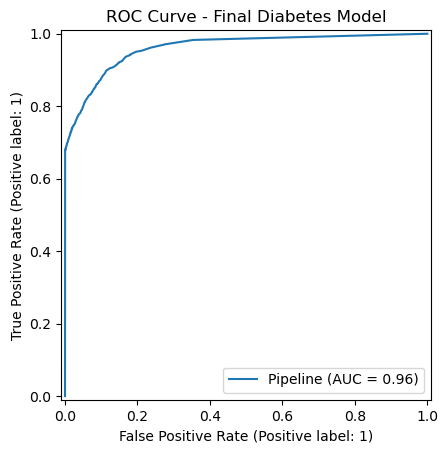

In [56]:
# 27. ROC curve. Why: The ROC curve shows how well the model separates diabetic and non-diabetic cases across thresholds.
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Final Diabetes Model")
plt.show()

In [58]:
#28. Save files
joblib.dump(best_model, "best_diabetes_model.pkl")

X.to_csv("X_features.csv", index=False)
y.to_csv("y_target.csv", index=False)
results_df.to_csv("model_comparison_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
